# Air Quality Monitoring at NEIU's Main Campus

Data collected by a [QuantAQ MODULAIR™](https://www.quant-aq.com/products/modulair) 
sensor mounted on the roof of the BBH building at Northeastern Illinois University's 
main campus in Chicago. The MODULAIR measures four gas-phase pollutants — ozone (O₃), 
nitrogen monoxide (NO), nitrogen dioxide (NO₂), and carbon monoxide (CO) — alongside 
particulate matter at three size fractions (PM₁, PM₂₅, and PM₁₀) at one-minute 
intervals. Data are retrieved from the QuantAQ cloud platform and plotted here in UTC. 

QuantQA data is archived in one minute intervals.

To install QuantQA's phython wrapper for the QuantAQ RESTful API

'pip install py-quantaq'

See https://quant-aq.github.io/py-quantaq/usage.html for details.

In [37]:
# Standard library
import datetime as dt
import calendar

# Third party
import logging
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
plt.rcParams['font.family'] = 'DejaVu Sans'
import calplot
from suntime import Sun
import quantaq
from quantaq.utils import to_dataframe
import matplotlib.transforms as transforms

# local packages
from aqi_colors import aqi_boxes

## API Credentials

In [34]:
from dotenv import load_dotenv

load_dotenv()  # loads .env from current directory
QUANTAQ_APIKEY = os.environ["QUANTAQ_APIKEY"]
client = quantaq.QuantAQAPIClient(api_key=QUANTAQ_APIKEY)

In [ ]:
#whoami = client.whoami()
#print (whoami)

In [ ]:
POLLUTANTS = ['co', 'co2', 'no', 'no2', 'o3', 'pm1', 'pm10', 'pm25']
SERIAL_NUMBER = "MOD-00079"
sensor = "QuantAQ MODULAIR\u2122"  # A string to identify the sensor

## Fetch data from QuantAQ Cloud

In [ ]:
# Example of how do fetch data for a date range (good for < 1 day). Not used below.
data = client.data.list(sn="MOD-00079", start="2024-01-01 00:00", stop="2024-01-01 23:59")
data = to_dataframe(data)

Download data for multiple years and write them locally

In [9]:
def download_year(client, sn, year):
    os.makedirs("data", exist_ok=True)
    df = []
    for date in pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31"):
        print(f"Fetching {date.date()}...", end="\r")
        try:
            day = to_dataframe(client.data.bydate(sn=sn, date=str(date.date())))
            if len(day) > 0:
                df.append(day)
        except Exception as e:
            print(f"\nError on {date.date()}: {e}")
    
    df = pd.concat(df)
    available_pollutants = [p for p in POLLUTANTS if p in df.columns]
    df = df.dropna(subset=available_pollutants, how='all')  # drop rows with no pollutant data
    outfile = f"data/quantaq_{year}.csv"
    df.to_csv(outfile, index=False)
    print(f"\nSaved {len(df)} rows to {outfile}")

# Run for each year
for year in [2022, 2023, 2024, 2025]:
    download_year(client,SERIAL_NUMBER, year)

Fetching 2022-12-31...
Saved 375419 rows to data/quantaq_2022.csv
Fetching 2023-12-31...
Saved 371181 rows to data/quantaq_2023.csv
Fetching 2024-12-31...
Saved 526383 rows to data/quantaq_2024.csv
Fetching 2025-12-31...
Saved 525494 rows to data/quantaq_2025.csv


In [10]:
# Download incomplete years in this cell
download_year(client,SERIAL_NUMBER,2026)

Fetching 2026-12-31...
Saved 201697 rows to data/quantaq_2026.csv


## Fetch locally archived data

In [19]:
def load_quantaq(year):
    filepath = f"data/quantaq_{year}.csv"
    df = pd.read_csv(filepath)
    df['timestamp_local'] = pd.to_datetime(df['timestamp_local'], utc=False)
    df.index = pd.to_datetime(df['timestamp'], utc=True)
    df = df.sort_index()                              # ensure chronological order
    df = df[~df.index.duplicated(keep='first')]       # drop duplicate timestamps
    available_pollutants = [p for p in POLLUTANTS if p in df.columns]
    df = df.dropna(subset=available_pollutants, how='all')  # drop rows with no pollutant data
    return df

aqdata_2022 = load_quantaq(2022)
aqdata_2023 = load_quantaq(2023)
aqdata_2024 = load_quantaq(2024)
aqdata_2025 = load_quantaq(2025)
aqdata_2026 = load_quantaq(2026)

## Data Resampling

In [20]:
daily_2022  = aqdata_2022.resample('D').mean(numeric_only=True)
hourly_2022 = aqdata_2022.resample('h').mean(numeric_only=True)
daily_2023  = aqdata_2023.resample('D').mean(numeric_only=True)
hourly_2023 = aqdata_2023.resample('h').mean(numeric_only=True)
daily_2024  = aqdata_2024.resample('D').mean(numeric_only=True)
hourly_2024 = aqdata_2024.resample('h').mean(numeric_only=True)
daily_2025  = aqdata_2025.resample('D').mean(numeric_only=True)
hourly_2025 = aqdata_2025.resample('h').mean(numeric_only=True)
daily_2026  = aqdata_2026.resample('D').mean(numeric_only=True)
hourly_2026 = aqdata_2026.resample('h').mean(numeric_only=True)

(<Figure size 1250x170 with 2 Axes>,
 array([<Axes: ylabel='2023'>], dtype=object))

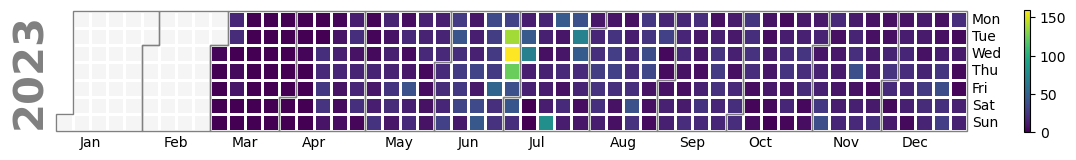

In [ ]:
# Data coverage
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
calplot.calplot(daily_2023['pm25'].tz_localize(None))

In [ ]:
# setup start time, time intervals, and end times

Ndays = 7
solar_day = dt.timedelta(days=1)

start_dt = dt.datetime(2023,6,21,tzinfo=dt.timezone.utc)
end_dt = start_dt + Ndays*solar_day
print("year=",start_dt.year)

# subset the data frame to include a restricted time interval
# so max values is selected for the plotted range

aqdata = aqdata_2023 
mask = (aqdata.index > start_dt) & (aqdata.index <= end_dt)
aqd = aqdata.loc[mask]

max_o3 = aqd['o3'].max()
max_co = aqd['co'].max()
max_pm1 = aqd['pm1'].max()
max_pm25 = aqd['pm25'].max()
max_pm10 = aqd['pm10'].max()
max_pm = max(max_pm1,max_pm25,max_pm10)

print('max o3 = ',max_o3)
max_ppb = max(aqd[['o3','no2','no']].max())


year= 2023
max o3 =  71.96


In [ ]:
# Nighttime shading: suntime returns sunset on the wrong UTC date when sunset 
# crosses midnight UTC (which it does for Chicago in summer). 
# Adding solar_day compensates.

sunset[i] = sun.get_sunset_time(day + solar_day).astimezone(dt.timezone.utc)

latitude  =  41.9803
longitude = -87.717 

sun=Sun(latitude,longitude)

dayname = [None]*(Ndays+1)

# Day of the week, e.g. Monday
dayname[0] = calendar.day_name[start_dt.weekday()]
print('dayname=',dayname)

sunrise = [None] * (Ndays + 1)
sunset  = [None] * (Ndays + 1)

for i in range(Ndays + 1):
    day        = start_dt + i * solar_day
    sunrise[i] = sun.get_sunrise_time(day).astimezone(dt.timezone.utc)
    sunset[i]  = sun.get_sunset_time(day + solar_day).astimezone(dt.timezone.utc)
    print(f"Day {i}: sunrise {sunrise[i].strftime('%Y-%m-%d %H:%M')}  "
          f"sunset {sunset[i].strftime('%Y-%m-%d %H:%M')}")

dayname= ['Wednesday', None, None, None, None, None, None, None]
Day 0: sunrise 2023-06-21 10:15  sunset 2023-06-22 01:30
Day 1: sunrise 2023-06-22 10:15  sunset 2023-06-23 01:30
Day 2: sunrise 2023-06-23 10:16  sunset 2023-06-24 01:30
Day 3: sunrise 2023-06-24 10:16  sunset 2023-06-25 01:30
Day 4: sunrise 2023-06-25 10:16  sunset 2023-06-26 01:30
Day 5: sunrise 2023-06-26 10:16  sunset 2023-06-27 01:30
Day 6: sunrise 2023-06-27 10:17  sunset 2023-06-28 01:30
Day 7: sunrise 2023-06-28 10:18  sunset 2023-06-29 01:30


## Timeseries Visualization

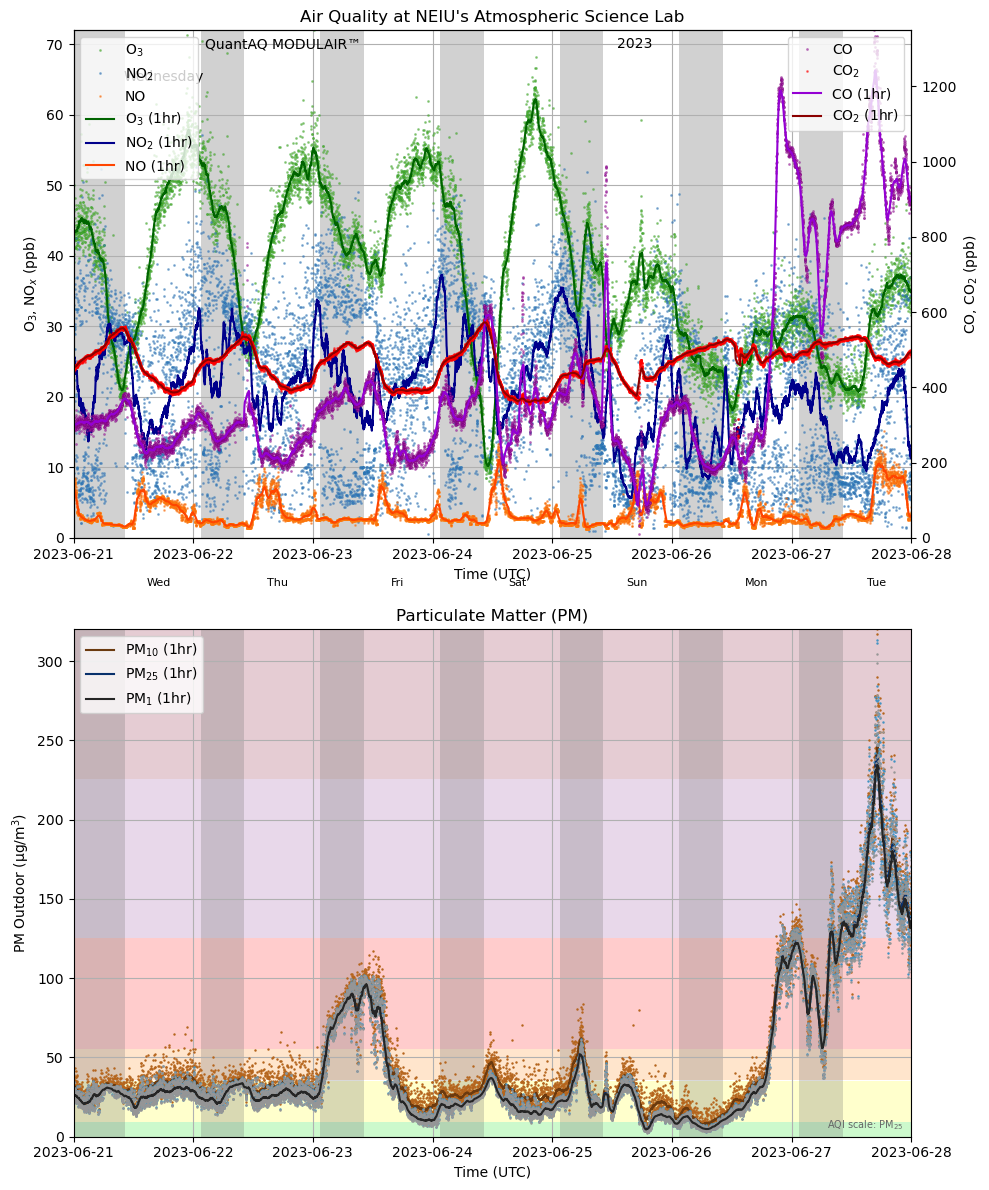

In [38]:
fig = plt.figure(figsize=(10,12))
ax1a = fig.add_subplot(2, # nrows
                       1, # ncols
                       1) # position

ax2a = fig.add_subplot(2, # nrows
                       1, # ncols
                       2) # position
ax1a.axis([start_dt,end_dt,0,max_ppb])

# Night before first sunrise
ax1a.add_patch(Rectangle(
    (start_dt, 0), sunrise[0] - start_dt, max_ppb,
    facecolor="dimgray", alpha=0.3, zorder=0,
))

for i in range(Ndays):
    ax1a.add_patch(Rectangle(
        (sunset[i], 0), sunrise[i+1] - sunset[i], max_ppb,
        facecolor="dimgray", alpha=0.3, zorder=0,
    ))
    
ax1a.set_title('Air Quality at NEIU\'s Atmospheric Science Lab')
ax1a.set_xlabel('Time (UTC)')
ax1a.set_ylabel('O${}_3$, NO${}_x$ (ppb)')
ax1a.grid(True)
ax1a.annotate(dayname[0], 
               xy=(start_dt+0.75*solar_day,0.90*max_ppb),
                horizontalalignment='center')
ax1a.annotate(sensor, 
               xy=(start_dt+0.25*(end_dt-start_dt),max_o3-1),
               verticalalignment='top',
               horizontalalignment='center',
               fontsize=10)
ax1a.annotate(start_dt.year, 
               xy=(start_dt+0.67*(end_dt-start_dt),max_o3-1),
               verticalalignment='top',
               horizontalalignment='center',
               fontsize=10)
ax1a.plot(aqd.index,
           aqd['o3'],
           label='O${}_3$',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='tab:olive',
           color='tab:green',
           alpha=0.5)
ax1a.plot(aqd.index,
           aqd['no2'],
           label='NO${}_2$',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='tab:purple',
           alpha=0.5)
ax1a.plot(aqd.index,
           aqd['no'],
           label='NO',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='tab:red',
           alpha=0.5)

ax1b = ax1a.twinx()
ax1b.set_ylabel('CO, CO${}_2$ (ppb)')
ax1b.axis([start_dt,end_dt,0,max_co])
ax1b.plot(aqd.index,
           aqd['co'],
           label='CO',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='violet',
           color='purple',
           alpha=0.5)
ax1b.plot(aqd.index,
           aqd['co2'],
           label='CO${}_2$',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='red',
           color='red',
           alpha=0.5)
ax1a.plot(aqd.index, aqd['o3'].rolling('60min',center=True).mean(),
           label="O${}_3$ (1hr)",color='darkgreen')
ax1a.plot(aqd.index, aqd['no2'].rolling('60min',center=True).mean(),
           label="NO${}_2$ (1hr)",color='darkblue')
ax1a.plot(aqd.index, aqd['no'].rolling('60min',center=True).mean(),
           label="NO (1hr)",color='orangered')
ax1b.plot(aqd.index, aqd['co'].rolling('60min',center=True).mean(),
           label="CO (1hr)",color='darkviolet')
ax1b.plot(aqd.index, aqd['co2'].rolling('60min',center=True).mean(),
           label="CO${}_2$ (1hr)",color='darkred')
ax1a.legend(loc='upper left')
ax1b.legend(loc='upper right')

# --- PM panel ---
ax2a.axis([start_dt, end_dt, 0, max_pm])

# AQI background bands (PM2.5 scale) — drawn first, behind everything
for box in aqi_boxes("pm25", start_dt, end_dt, max_pm, alpha=0.2):
    box.set_zorder(0)
    ax2a.add_patch(box)

# Nighttime shading on top of AQI bands
ax2a.add_patch(Rectangle(
    (start_dt, 0), sunrise[0] - start_dt, max_pm,
    facecolor="dimgray", alpha=0.25, zorder=1,
))
for i in range(Ndays):
    ax2a.add_patch(Rectangle(
        (sunset[i], 0), sunrise[i+1] - sunset[i], max_pm,
        facecolor="dimgray", alpha=0.25, zorder=1,
    ))

ax2a.grid(True, zorder=2)

# PM10 — warm brown
ax2a.plot(aqd.index,
          aqd['pm10'],
          linestyle='none',
          marker='o',
          markersize=0.75,
          color='#b5651d',  # sienna
          )
ax2a.plot(aqd.index,
          aqd['pm10'].rolling('60min', center=True).mean(),
          label="PM${}_{10}$ (1hr)",
          color='#6b3a0f',  # dark brown
          linewidth=1.5)

# PM2.5 — blue (the policy-relevant quantity)
ax2a.plot(aqd.index,
          aqd['pm25'],
          linestyle='none',
          marker='o',
          markersize=0.75,
          color='#4393c3',  # cornflower blue
          )
ax2a.plot(aqd.index,
          aqd['pm25'].rolling('60min', center=True).mean(),
          label="PM${}_{25}$ (1hr)",
          color='#08306b',  # navy
          linewidth=1.5)

# PM1 — gray (smallest fraction, recedes visually)
ax2a.plot(aqd.index,
          aqd['pm1'],
          linestyle='none',
          marker='o',
          markersize=0.75,
          color='#969696',  # medium gray
          )
ax2a.plot(aqd.index,
          aqd['pm1'].rolling('60min', center=True).mean(),
          label="PM${}_{1}$ (1hr)",
          color='#252525',  # near-black
          linewidth=1.5)

ax2a.set_title('Particulate Matter (PM)')
ax2a.set_xlabel('Time (UTC)')
ax2a.set_ylabel('PM Outdoor (µg/m${}^3$)')

# Note that AQI background colors correspond to the PM2.5 scale
ax2a.annotate('AQI scale: PM${}_{25}$',
              xy=(0.99, 0.01),
              xycoords='axes fraction',
              ha='right', va='bottom',
              fontsize=7,
              color='0.4')

ax2a.legend(loc='upper left')

fig.tight_layout(h_pad=2)

blended = transforms.blended_transform_factory(ax1a.transData, ax1a.transAxes)

for i in range(Ndays + 1):
    noon_utc = start_dt + i * solar_day + dt.timedelta(hours=17)
    if start_dt <= noon_utc <= end_dt:
        ax1a.annotate(
            calendar.day_abbr[(start_dt + i * solar_day).weekday()],
            xy=(noon_utc, -0.08),
            xycoords=blended,
            ha='center', va='top',
            fontsize=8,
        )

plt.show()

In [39]:
fig.savefig("figures/QAQ_time_series.png", dpi=150, bbox_inches="tight")
fig.savefig("figures/QAQ_time_series.pdf", bbox_inches="tight")
print("Saved QuantAQ figures")

Saved QuantAQ figures
